# EDA — Fashion Product Images

**Módulo 1 — Clasificación de productos**

Análisis exploratorio del dataset Fashion Product Images (Kaggle) antes de entrenar.
Objetivo: entender la distribución de clases, calidad de imágenes y decidir qué nivel de categoría usar.

In [ ]:
# Montar Drive y configurar entorno (Colab)
from google.colab import drive
drive.mount('/content/drive')

!pip install -q polars seaborn

Mounted at /content/drive


In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import numpy as np

DATA_DIR = Path('/content/drive/MyDrive/smartretail360/data/external/fashion_products')
IMAGES_DIR = DATA_DIR / 'images'
# TODO: ajustar ruta si el dataset está en otra ubicación

## 1. Cargar metadata del dataset

In [ ]:
# TODO: cargar styles.csv con polars
df = pl.read_csv(DATA_DIR / 'styles.csv', ignore_errors=True, truncate_ragged_lines=True)
print(df.shape)
df.head()

(44446, 10)


sys:1: UserWarning: CSV malformed: expected 720 rows, actual 2778 rows, in chunk starting at byte offset 1211387, length 270732


id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
i64,str,str,str,str,str,str,i64,str,str
15970,"""Men""","""Apparel""","""Topwear""","""Shirts""","""Navy Blue""","""Fall""",2011,"""Casual""","""Turtle Check Men Navy Blue Shi…"
39386,"""Men""","""Apparel""","""Bottomwear""","""Jeans""","""Blue""","""Summer""",2012,"""Casual""","""Peter England Men Party Blue J…"
59263,"""Women""","""Accessories""","""Watches""","""Watches""","""Silver""","""Winter""",2016,"""Casual""","""Titan Women Silver Watch"""
21379,"""Men""","""Apparel""","""Bottomwear""","""Track Pants""","""Black""","""Fall""",2011,"""Casual""","""Manchester United Men Solid Bl…"
53759,"""Men""","""Apparel""","""Topwear""","""Tshirts""","""Grey""","""Summer""",2012,"""Casual""","""Puma Men Grey T-shirt"""


## 2. Distribución de clases

shape: (7, 2)
┌────────────────┬───────┐
│ masterCategory ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ Apparel        ┆ 21400 │
│ Accessories    ┆ 11289 │
│ Footwear       ┆ 9222  │
│ Personal Care  ┆ 2404  │
│ Free Items     ┆ 105   │
│ Sporting Goods ┆ 25    │
│ Home           ┆ 1     │
└────────────────┴───────┘


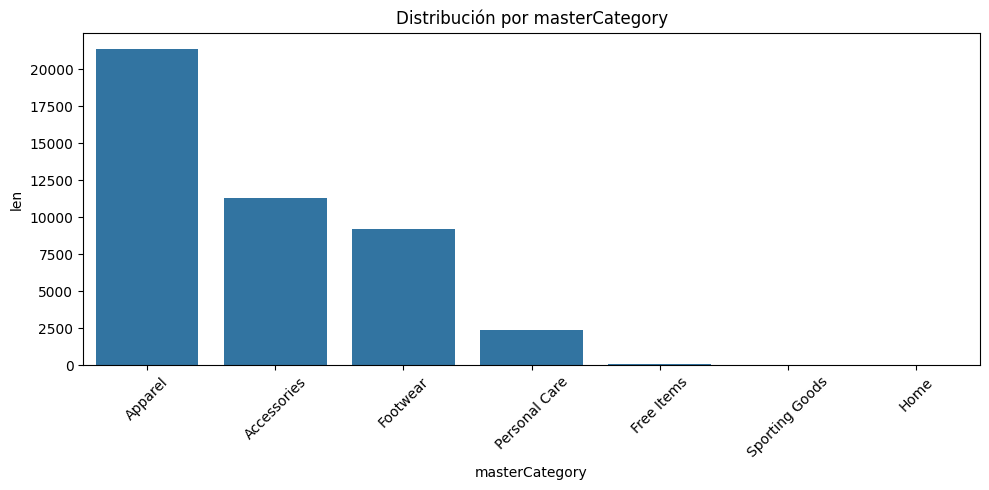

shape: (20, 2)
┌──────────────────────────┬───────┐
│ subCategory              ┆ len   │
│ ---                      ┆ ---   │
│ str                      ┆ u32   │
╞══════════════════════════╪═══════╡
│ Topwear                  ┆ 15405 │
│ Shoes                    ┆ 7344  │
│ Bags                     ┆ 3055  │
│ Bottomwear               ┆ 2694  │
│ Watches                  ┆ 2542  │
│ …                        ┆ …     │
│ Dress                    ┆ 478   │
│ Loungewear and Nightwear ┆ 470   │
│ Saree                    ┆ 427   │
│ Nails                    ┆ 329   │
│ Makeup                   ┆ 307   │
└──────────────────────────┴───────┘


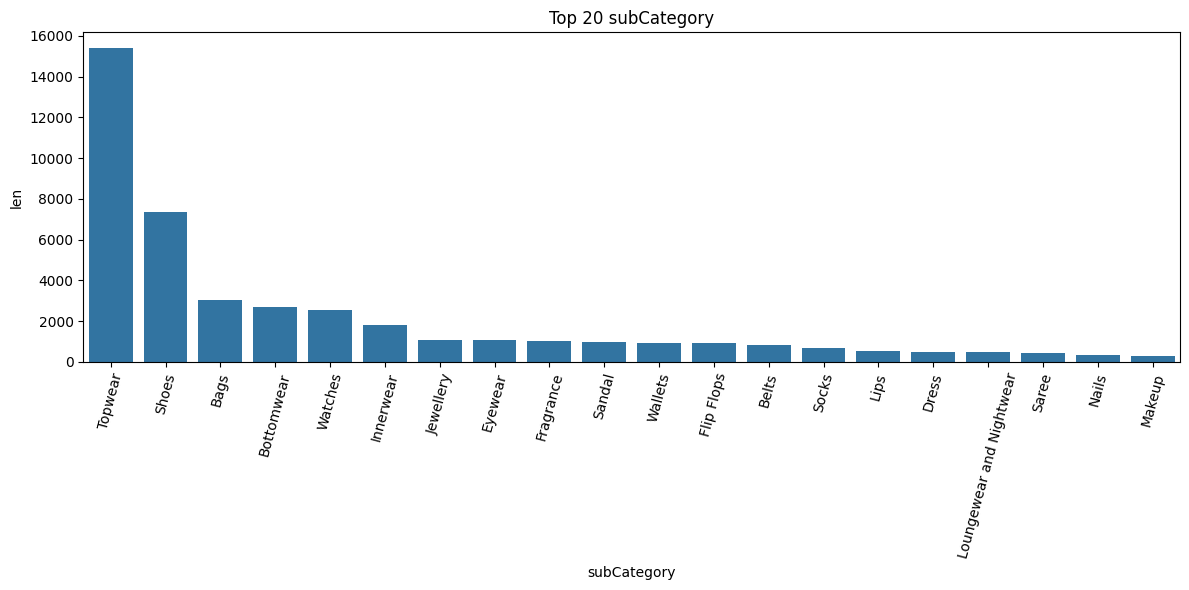

In [ ]:
# TODO: contar imágenes por masterCategory y subCategory
# Visualizar con barplot (seaborn)
# Pregunta clave: ¿está balanceado? ¿cuántas clases son viables?
master_counts = df.group_by('masterCategory').len().sort('len', descending=True)
print(master_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=master_counts.to_pandas(), x='masterCategory', y='len')
plt.title('Distribución por masterCategory')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sub_counts = df.group_by('subCategory').len().sort('len', descending=True)
print(sub_counts.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(data=sub_counts.head(20).to_pandas(), x='subCategory', y='len')
plt.title('Top 20 subCategory')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 3. Visualización de muestras por categoría

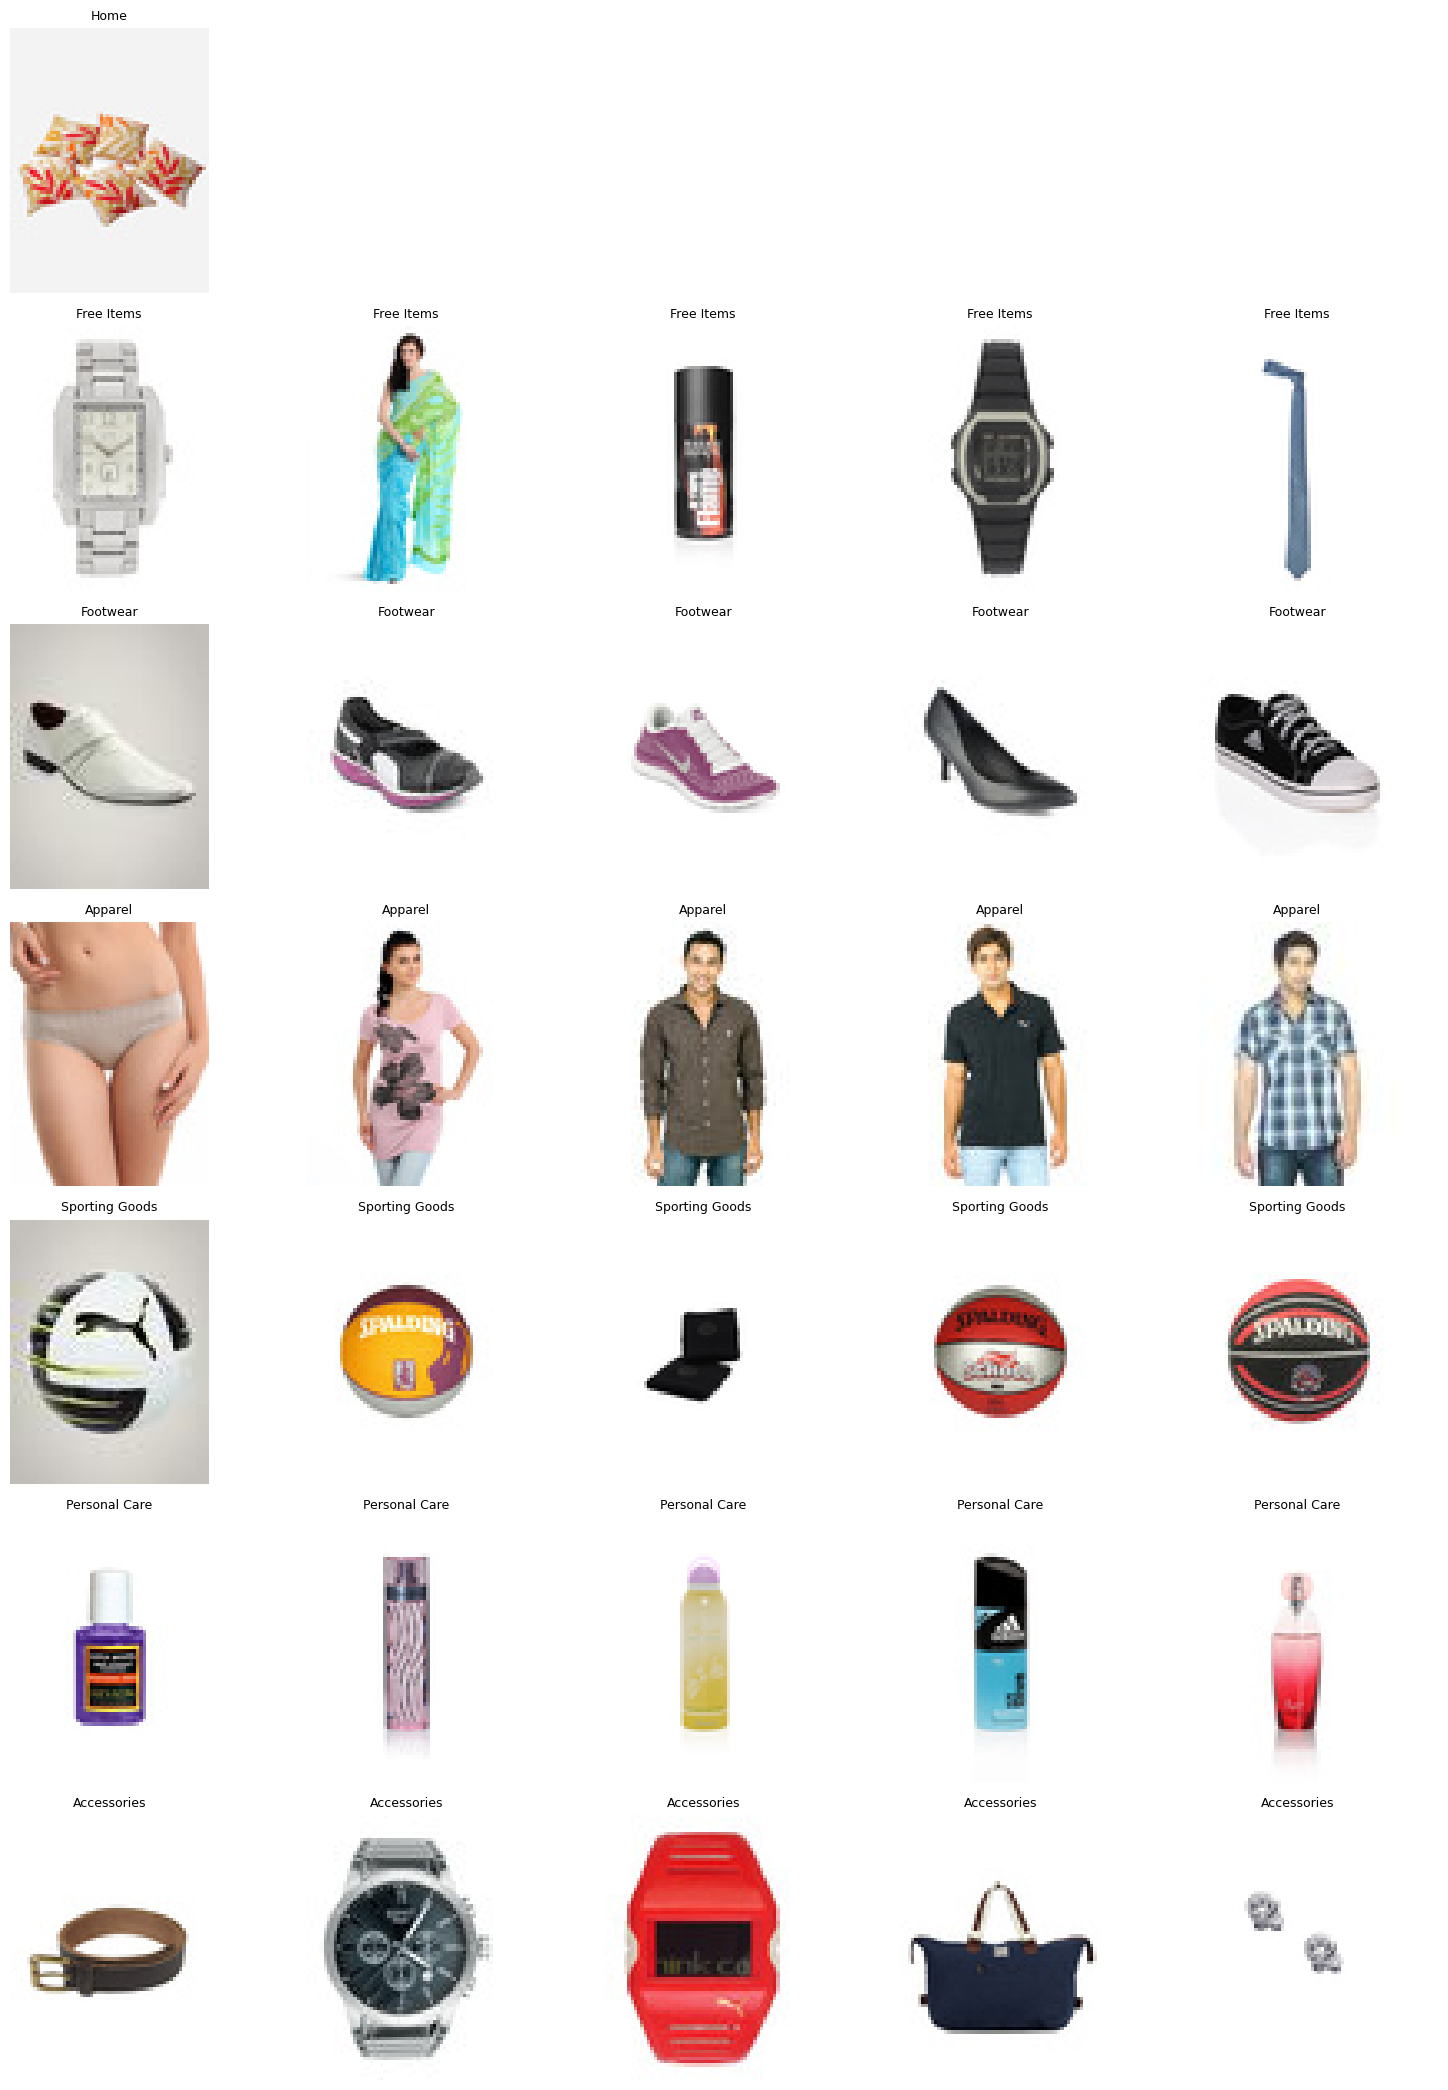

In [ ]:
# TODO: mostrar 4-5 imágenes por clase de masterCategory
# Verificar calidad visual y consistencia de fondo
categories = df['masterCategory'].unique().to_list()

fig, axes = plt.subplots(len(categories), 5, figsize=(15, 3 * len(categories)))

for i, cat in enumerate(categories):
    subset = df.filter(pl.col('masterCategory') == cat)
    n_samples = min(5, subset.shape[0])
    sample_ids = subset['id'].sample(n_samples, seed=42).to_list()
    for j in range(5):
        if j < len(sample_ids):
            img_id = sample_ids[j]
            img_path = IMAGES_DIR / f'{img_id}.jpg'
            if img_path.exists():
                img = Image.open(img_path)
                axes[i, j].imshow(img)
                axes[i, j].set_title(cat, fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

## 4. Estadísticas de dimensiones de imagen

Ancho: min=60, max=60, media=60.0
Alto: min=80, max=80, media=80.0


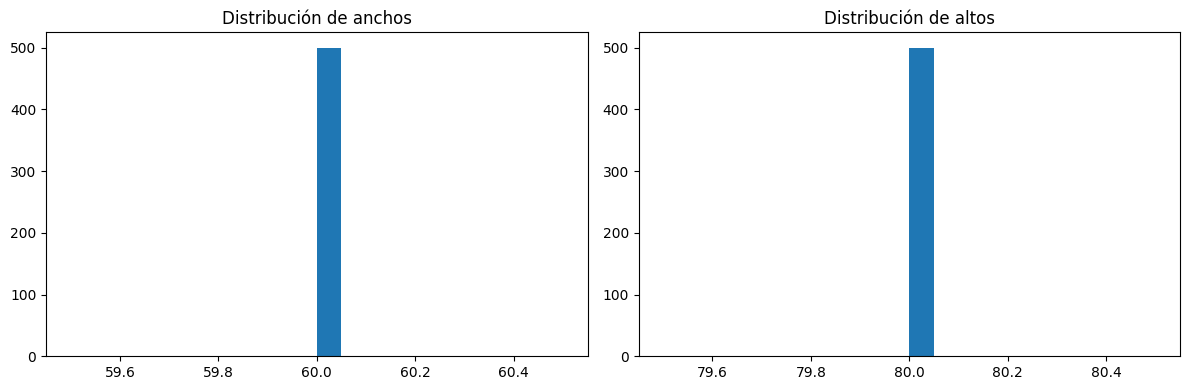

In [ ]:
# TODO: samplear ~500 imágenes, medir ancho y alto
# Histograma de dimensiones
# ¿Son todas 60x80 o hay variaciones?
sample_ids = df['id'].sample(500, seed=42).to_list()
widths, heights = [], []

for img_id in sample_ids:
    img_path = IMAGES_DIR / f'{img_id}.jpg'
    if img_path.exists():
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Ancho: min={min(widths)}, max={max(widths)}, media={np.mean(widths):.1f}")
print(f"Alto: min={min(heights)}, max={max(heights)}, media={np.mean(heights):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20)
axes[0].set_title('Distribución de anchos')
axes[1].hist(heights, bins=20)
axes[1].set_title('Distribución de altos')
plt.tight_layout()
plt.show()

## 5. Detección de inconsistencias

In [ ]:
# Inconsistencia encontrada en el CSV: parseo irregular
# El warning de polars reporta una fila mal formada (esperaba 720 campos, encontró 2778)
# debido a un valor de texto en productDisplayName que contiene comas sin comillas.
# Solución aplicada: truncate_ragged_lines=True trunca los campos sobrantes,
# manteniendo el resto de la fila intacta. No se pierden filas, solo se recorta
# el texto excedente en esa columna para esa fila puntual.
print("CSV cargado con truncate_ragged_lines=True debido a filas mal formadas (comas sin escapar en productDisplayName)")

existing_ids = set(int(p.stem) for p in IMAGES_DIR.glob('*.jpg'))
csv_ids = set(df['id'].to_list())

missing_images = csv_ids - existing_ids
print(f"IDs en CSV sin imagen: {len(missing_images)}")

nulls = df.null_count()
print(nulls)

duplicates = df.filter(pl.col('id').is_duplicated())
print(f"IDs duplicados: {duplicates.shape[0]}")

CSV cargado con truncate_ragged_lines=True debido a filas mal formadas (comas sin escapar en productDisplayName)
IDs en CSV sin imagen: 5
shape: (1, 10)
┌─────┬────────┬────────────────┬─────────────┬───┬────────┬──────┬───────┬────────────────────┐
│ id  ┆ gender ┆ masterCategory ┆ subCategory ┆ … ┆ season ┆ year ┆ usage ┆ productDisplayName │
│ --- ┆ ---    ┆ ---            ┆ ---         ┆   ┆ ---    ┆ ---  ┆ ---   ┆ ---                │
│ u32 ┆ u32    ┆ u32            ┆ u32         ┆   ┆ u32    ┆ u32  ┆ u32   ┆ u32                │
╞═════╪════════╪════════════════╪═════════════╪═══╪════════╪══════╪═══════╪════════════════════╡
│ 0   ┆ 0      ┆ 0              ┆ 0           ┆ … ┆ 21     ┆ 1    ┆ 1     ┆ 0                  │
└─────┴────────┴────────────────┴─────────────┴───┴────────┴──────┴───────┴────────────────────┘
IDs duplicados: 0


## 6. Decisión: masterCategory vs subCategory

In [ ]:
# TODO: documentar la decisión aquí con justificación basada en los datos
# Opciones:
#   masterCategory → 5 clases, más balanceado, más fácil de aprender
#   subCategory    → ~45 clases, más granular, requiere más data y épocas
n_master = df['masterCategory'].n_unique()
n_sub = df['subCategory'].n_unique()
print(f"masterCategory: {n_master} clases")
print(f"subCategory: {n_sub} clases")

print('Decisión: usar masterCategory — ajustar según los resultados de la sección 2')

masterCategory: 7 clases
subCategory: 45 clases
Decisión: usar masterCategory — ajustar según los resultados de la sección 2


## 7. Conclusiones

```
TODO: completar tras el análisis
- Distribución de clases (masterCategory): dataset muy desbalanceado. 7 clases en total: Apparel (21400), Accessories (11289), Footwear (9222), Personal Care (2404), Free Items (105), Sporting Goods (25), Home (1). Las últimas tres son prácticamente inviables para entrenar (Home tiene solo 1 muestra).
- Distribución de subCategory: ~45 clases con desbalance aún mayor — desde Topwear (15405) hasta categorías con apenas 300-400 muestras (Saree, Nails, Makeup). Demasiado granular y desbalanceado para usar directamente sin agrupar o filtrar.
- Dimensiones de imagen: completamente uniformes, 60x80 px en todas las muestras analizadas. No hay variación que requiera normalización adicional de tamaño.
- Imágenes problemáticas: 5 IDs presentes en el CSV sin imagen correspondiente en disco (deberán excluirse del dataset de entrenamiento). 0 valores nulos en todas las columnas. 0 IDs duplicados.
- Inconsistencia en el CSV: el archivo styles.csv tiene filas mal formadas (texto sin comillas en productDisplayName que rompe el parseo). Se resolvió con truncate_ragged_lines=True sin pérdida de filas.
- Decisión de categoría: se usará masterCategory para el entrenamiento. Tiene solo 7 clases (más manejable que las ~45 de subCategory) pero aun así requiere acción sobre las clases extremadamente pequeñas (Home, Sporting Goods, Free Items) antes de entrenar — probablemente excluirlas o fusionarlas, ya que no es viable entrenar un clasificador con 1 sola muestra.
- Técnica de balanceo elegida: dado el desbalance entre Apparel/Accessories/Footwear (las 3 clases viables y mayoritarias) y el resto, se propone: (1) excluir Home, Sporting Goods y Free Items del entrenamiento por insuficiencia de datos, y (2) aplicar class_weight="balanced" en Keras para compensar el desbalance restante entre Apparel, Accessories, Footwear y Personal Care.
```